# VQCFD Results Analysis

The reusable logic lives in `analysis.py`. This notebook only contains run selections and plotting options.


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import analysis as an

an.configure_plots()
RESULTS_ROOT = an.RESULTS_ROOT
RESULTS_ROOT


PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results')

## Discover saved runs


In [2]:
runs = an.list_runs()
an.print_runs(runs)


N2_L1              mode=noise_free   N=2   L=1   circuit=default                initial_state=sine               n_params=4    saved=True variance=False
N2_L2              mode=noise_free   N=2   L=2   circuit=default                initial_state=sine               n_params=6    saved=True variance=False
N2_L3              mode=noise_free   N=2   L=3   circuit=default                initial_state=sine               n_params=8    saved=True variance=False
N2_L4              mode=noise_free   N=2   L=4   circuit=default                initial_state=sine               n_params=10   saved=True variance=False
N2_L5              mode=noise_free   N=2   L=5   circuit=default                initial_state=sine               n_params=12   saved=True variance=False
N2_L6              mode=noise_free   N=2   L=6   circuit=default                initial_state=sine               n_params=14   saved=True variance=False
N2_L7              mode=noise_free   N=2   L=7   circuit=default                in

In [20]:
# Optional filters: n=..., l=...
preset_rows = an.list_initial_param_presets(l=1, show_variants=False)


N=2, L=1 | default_len=5 | default_mse=2.299774959702107e-14
N=3, L=1 | default_len=7 | default_mse=0.017278574634361943
N=4, L=1 | default_len=9 | default_mse=0.026448571369803636
N=5, L=1 | default_len=11 | default_mse=0.026839737986057908
N=6, L=1 | default_len=13 | default_mse=0.026308669655778574
N=7, L=1 | default_len=15 | default_mse=0.025868179172688327
N=8, L=1 | default_len=17 | default_mse=0.0255992629189411
N=9, L=1 | default_len=19 | default_mse=0.025467634556539696
N=10, L=1 | default_len=21 | default_mse=0.025382174331034273
count=9 presets


## Inspect one run


In [ ]:
DIR_LABEL = "N5"
LABEL = "L5"

run = an.load_run(DIR_LABEL, LABEL)
run


RunData(dir_label='N5', label='L3', full_label='N5_L3', results_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5'), data_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5/data_L3'), fig_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5/figures_L3'), manifest={'cobyla_maxiter': 100000, 'cobyla_tol': 1e-05, 'compute_expr_cap': True, 'data_dir': 'results/results_N5/data_L3', 'dir_label': 'N5', 'dt': 0.01, 'expr_bins': 100, 'expr_entcap_samples': 100000, 'fig_dir': 'results/results_N5/figures_L3', 'grad_tol': 0.001, 'init_param_random_center': 2.891592653589793, 'init_param_random_scale': 0.1, 'initial_params': None, 'initial_params_presets_file': 'initial_params_presets.yaml', 'initial_params_variant': None, 'l': 3, 'label': 'L3', 'manifest_path': 'results/results_N5/manifest_N5_L3.yaml', 'max_iter': 100, 'mode': 'noise_free', 'mu': 0.01, 'n': 5, 'n_timesteps': 28, 'n_total': 32, 'optimization_steps': 1000, 'pa

In [16]:
print("manifest path:", run.files["manifest"])
print("values yaml path:", run.files["values_yaml"])
print("values keys:", list(run.values.keys()))
run.values


manifest path: /Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5/manifest_N5_L3.yaml
values yaml path: /Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5/data_L3/values_N5_L3.yaml
values keys: ['n', 'l', 'shots', 'max_iter', 't_total', 'mu', 'dt', 'plat_tol', 'patience', 'initial_params_source', 'expressibility', 'entangling_capability', 'initial_fit_mse', 'shots_used_per_timestep', 'shots_used_total']


{'n': 5,
 'l': 3,
 'shots': 100,
 'max_iter': 100,
 't_total': 0.29,
 'mu': 0.01,
 'dt': 0.01,
 'plat_tol': 0.00015,
 'patience': 15,
 'initial_params_source': 'preset',
 'expressibility': 0.15339622384009272,
 'entangling_capability': 0.7397000251553031,
 'initial_fit_mse': 2.8212053616355398e-05,
 'shots_used_per_timestep': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'shots_used_total': 0}

In [17]:
costs = run.costs
times = run.times
params = run.params
variance = run.variance

print("costs:", None if costs is None else costs.shape)
print("times:", None if times is None else times.shape)
print("params:", None if params is None else params.shape)
print("variance:", variance)


costs: (28,)
times: (28,)
params: (29, 21)
variance: None


In [18]:
cost_histories = an.load_per_timestep_histories(run, "cost_iter")
param_histories = an.load_per_timestep_histories(run, "params_iter")
print("cost_iter timesteps:", len(cost_histories))
print("params_iter timesteps:", len(param_histories))


cost_iter timesteps: 28
params_iter timesteps: 0


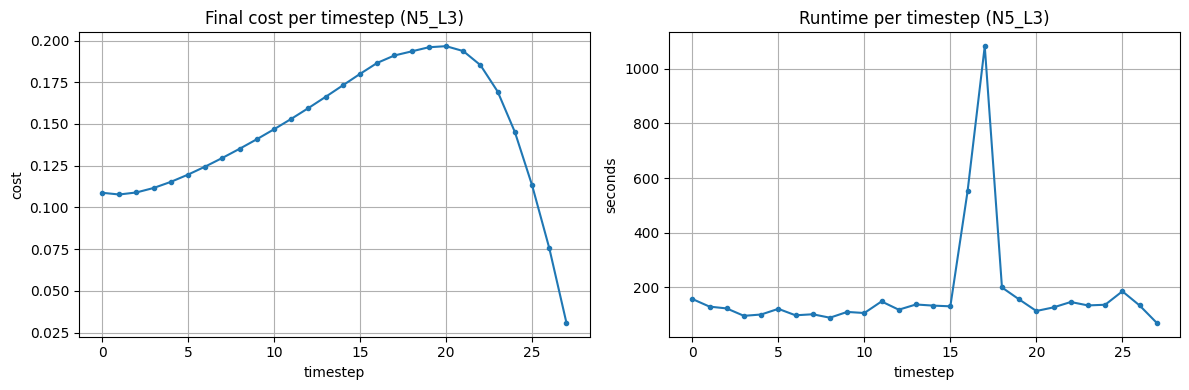

In [19]:
an.plot_costs_and_times(run);


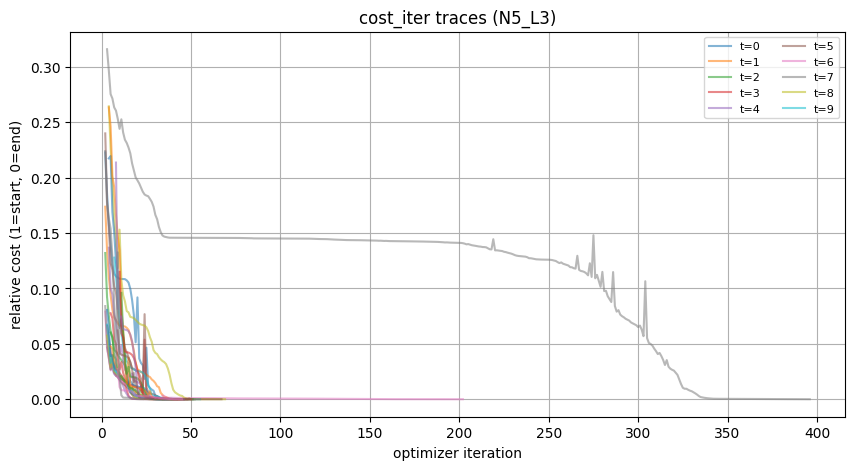

In [20]:
an.plot_cost_histories(
    run,
    normalize=True,
    remove_outliers=True,
    outlier_method="iqr",       # "iqr" or "percentile"
    outlier_factor=3.0,
    outlier_percentiles=(1.0, 99.0),
    show_first_n_labels=10,
);


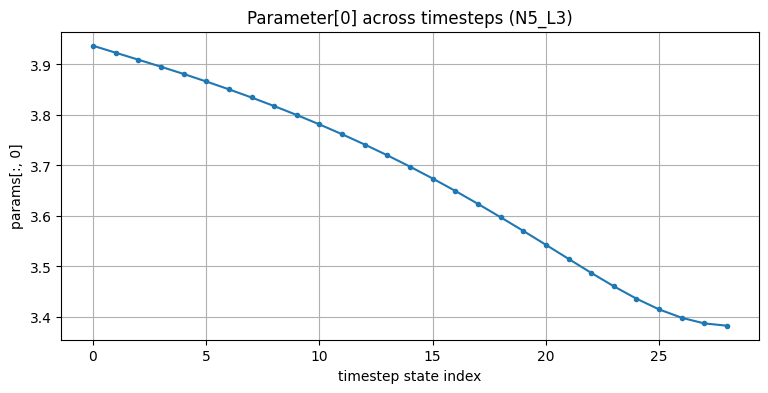

In [21]:
an.plot_parameter_history(run, parameter_index=0);


shots_used_total: 0


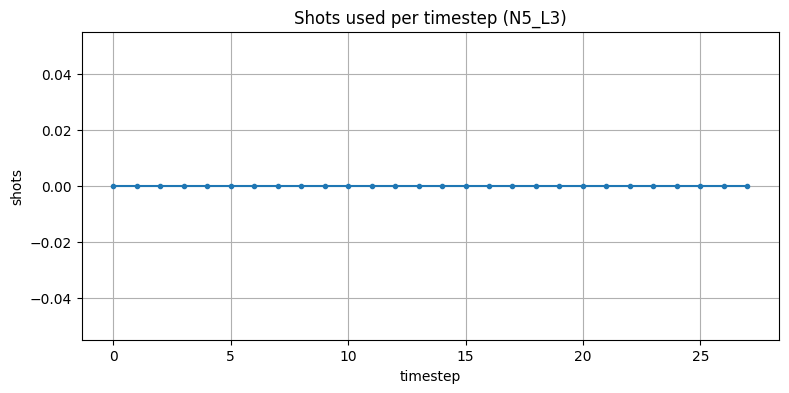

In [22]:
an.plot_shots(run);


## Classical and quantum fields at one timestep

Use `TIMESTEP = 0` for the initial state, a positive saved-state index, or `-1` for the final state. The plot reports MSE, R², and normalized squared-overlap fidelity.


In [24]:
DIR_LABEL = "N5"
LABEL = "L5"

run = an.load_run(DIR_LABEL, LABEL)
run

RunData(dir_label='N5', label='L5', full_label='N5_L5', results_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5'), data_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5/data_L5'), fig_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5/figures_L5'), manifest={'cobyla_maxiter': 100000, 'cobyla_tol': 1e-05, 'compute_expr_cap': True, 'data_dir': 'results/results_N5/data_L5', 'dir_label': 'N5', 'dt': 0.01, 'expr_bins': 100, 'expr_entcap_samples': 100000, 'fig_dir': 'results/results_N5/figures_L5', 'grad_tol': 0.001, 'init_param_random_center': 2.891592653589793, 'init_param_random_scale': 0.1, 'initial_params': None, 'initial_params_presets_file': 'initial_params_presets.yaml', 'initial_params_variant': None, 'l': 5, 'label': 'L5', 'manifest_path': 'results/results_N5/manifest_N5_L5.yaml', 'max_iter': 100, 'mode': 'noise_free', 'mu': 0.01, 'n': 5, 'n_timesteps': 28, 'n_total': 32, 'optimization_steps': 1000, 'pa

timestep    2.800000e+01
time        2.800000e-01
MSE         1.377035e-08
R2          1.000000e+00
Fidelity    1.000000e+00
dtype: float64

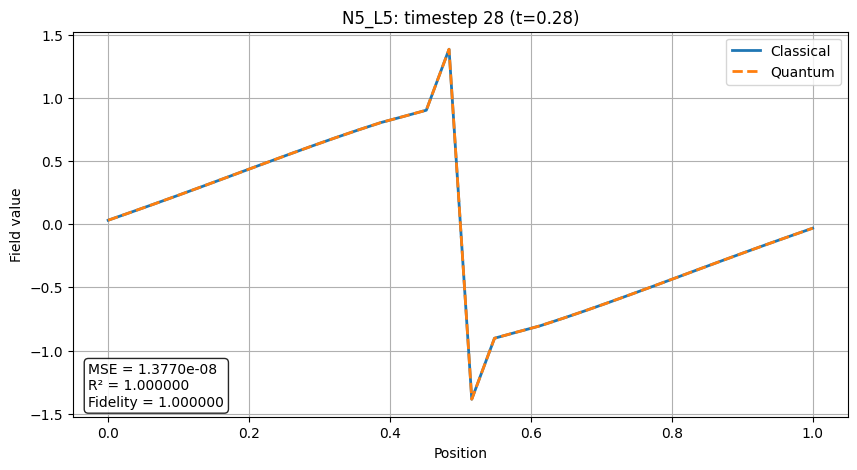

In [25]:
TIMESTEP = -1

timestep_comparison, ax = an.plot_run_timestep_comparison(run, timestep=TIMESTEP)
pd.Series({key: timestep_comparison[key] for key in ["timestep", "time", "MSE", "R2", "Fidelity"]})


## Expressibility and entangling capability


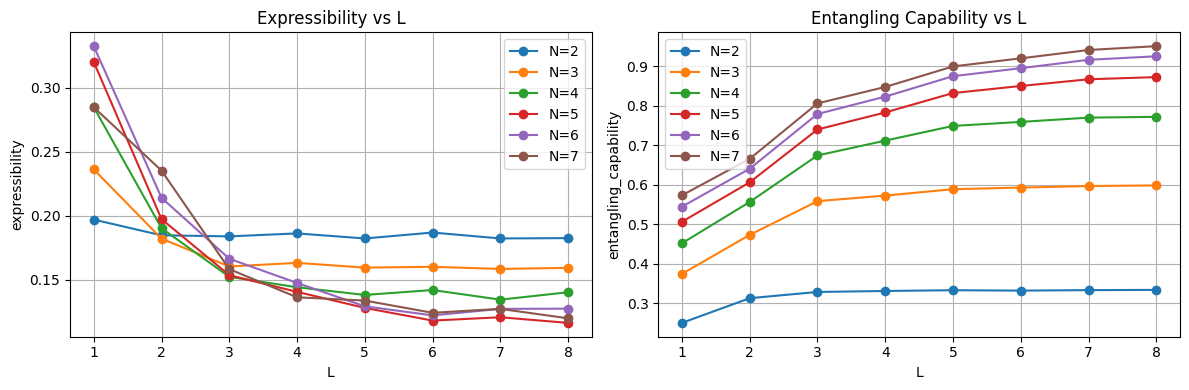

In [3]:
# Add (dir_label, label) pairs here. These select independently saved *_expr results.
# With an empty selection, discover *_expr results and full runs containing either metric.
EXPR_ENTCAP_SELECTION = []

if EXPR_ENTCAP_SELECTION:
    expr_runs = an.load_expr_runs(EXPR_ENTCAP_SELECTION)
else:
    expr_runs = an.discover_expr_runs(include_full_runs=True)

if expr_runs:
    an.plot_expr_entcap_vs_l(expr_runs, n_filter=None)
else:
    print("No selected runs contain expressibility or entangling-capability values.")


## Configurable multi-run comparison table

The table contains N, L, the number of circuit parameters, variance, expressibility, entangling capability, circuit, initial state, and final-state R²/fidelity/MSE. Variance-only runs can be supplied separately and are matched to simulation runs by `(N, L, Circuit)`. Leave `RUN_SELECTION` empty to select every available non-variance run with saved parameters.

Older manifests do not record a circuit name, so they are shown as `default`. Use `CIRCUIT_OVERRIDES` for older runs whose circuit is known from their label or experiment notes.


In [4]:
RUN_SELECTION = [
    # ("N3", "L2"),
    # ("N4", "L3"),
]

# Optional explicit variance selection. Leave empty to use all discovered variance runs.
VARIANCE_SELECTION = []

# Example: {"experiment_uni2_N4L3": "uni2"}
CIRCUIT_OVERRIDES = {}

selected_runs = an.load_runs(RUN_SELECTION) if RUN_SELECTION else an.discover_simulation_runs()
variance_runs = (
    [an.load_variance_run(d, label) for d, label in VARIANCE_SELECTION]
    if VARIANCE_SELECTION
    else an.discover_variance_runs()
)

run_table = an.build_run_table(
    selected_runs,
    variance_runs=variance_runs,
    circuit_overrides=CIRCUIT_OVERRIDES,
)
run_table


/Users/joel/Documents/MA/Code/VQCFD_quimb/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:542: RuntimeWarning: overflow encountered in multiply
  - (dt / (2 * dx)) * previous * (right - left)
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:541: RuntimeWarning: invalid value encountered in subtract
  + (mu * dt / dx**2) * (right - 2 * previous + left)
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:541: RuntimeWarning: invalid value encountered in add
  + (mu * dt / dx**2) * (right - 2 * previous + left)
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:540: RuntimeWarning: invalid value encountered in add
  previous
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:542: RuntimeWarning: invalid value encountered in subtract
 

,Run,N,L,NumberOfParameters,Var,Expressibility,EntanglingCapability,Circuit,InitialState,R2,Fidelity,MSE
0,N2_L1,2,1,4,0.317165,0.196844,0.250619,default,sine,1.000000,1.000000,2.326261e-11
1,N2_L2,2,2,6,0.296537,0.184564,0.313082,default,sine,1.000000,1.000000,1.484466e-09
2,N2_L3,2,3,8,NaN,0.183727,0.328842,default,sine,1.000000,1.000000,4.356663e-09
3,N2_L4,2,4,10,0.279786,0.186045,0.331312,default,sine,1.000000,1.000000,2.631006e-10
4,N2_L5,2,5,12,NaN,0.182096,0.333216,default,sine,1.000000,1.000000,7.970332e-11
5,N2_L6,2,6,14,NaN,0.186717,0.332239,default,sine,1.000000,1.000000,2.066578e-09
6,N2_L7,2,7,16,NaN,0.182113,0.333437,default,sine,1.000000,1.000000,6.126734e-09
7,N2_L8,2,8,18,0.270733,0.182373,0.334074,default,sine,1.000000,1.000000,3.746273e-09
8,N3_L1,3,1,6,0.144278,0.236094,0.374424,default,sine,0.761041,0.813665,2.520184e-01
9,N3_L2,3,2,9,0.138905,0.181958,0.473112,default,sine,1.000000,1.000000,4.745697e-09


,Run,N,L,NumberOfParameters,Var,Expressibility,EntanglingCapability,Circuit,InitialState,R2,Fidelity,MSE
0,N2_L1,2,1,4,0.317165,0.196844,0.250619,default,sine,1.000000,1.000000,2.326261e-11
1,N2_L2,2,2,6,0.296537,0.184564,0.313082,default,sine,1.000000,1.000000,1.484466e-09
2,N2_L3,2,3,8,NaN,0.183727,0.328842,default,sine,1.000000,1.000000,4.356663e-09
3,N2_L4,2,4,10,0.279786,0.186045,0.331312,default,sine,1.000000,1.000000,2.631006e-10
4,N2_L5,2,5,12,NaN,0.182096,0.333216,default,sine,1.000000,1.000000,7.970332e-11
5,N2_L6,2,6,14,NaN,0.186717,0.332239,default,sine,1.000000,1.000000,2.066578e-09
6,N2_L7,2,7,16,NaN,0.182113,0.333437,default,sine,1.000000,1.000000,6.126734e-09
7,N2_L8,2,8,18,0.270733,0.182373,0.334074,default,sine,1.000000,1.000000,3.746273e-09
8,N3_L1,3,1,6,0.144278,0.236094,0.374424,default,sine,0.761041,0.813665,2.520184e-01
9,N3_L2,3,2,9,0.138905,0.181958,0.473112,default,sine,1.000000,1.000000,4.745697e-09


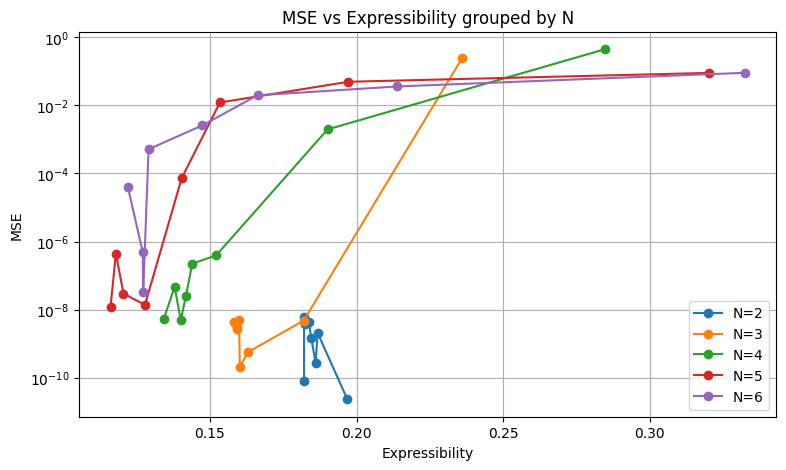

In [ ]:
# Any columns in an.RUN_TABLE_COLUMNS can be used for X, Y, or GROUP_BY.
X = "Expressibility"
Y = "MSE"
GROUP_BY = "N"          # "N", "L", "Circuit", "InitialState", another column, or None

NS = [2,3,4,5,6] # None               # e.g. [3, 4, 5]
LS = None               # e.g. [1, 2, 3]
CIRCUITS = None         # e.g. ["default", "uni2", "brickwork_ring_ry"]
INITIAL_STATES = None   # e.g. ["sine", "tapered_gaussian"]
a
filtered_table, ax = an.plot_run_table(
    run_table,
    x=X,
    y=Y,
    ns=NS,
    ls=LS,
    circuits=CIRCUITS,
    initial_states=INITIAL_STATES,
    group_by=GROUP_BY,
    kind="line",        # "line" or "scatter"
    log_y=True,
)
filtered_table
